In [1]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Milestone 3 – Feature Engineering  
## Smart Energy Consumption Analysis and Prediction using Machine Learning  

**Intern Name:** Kunal Bhardwaj  
**GitHub Branch:** kunal_branch  
**Dataset:** Individual Household Electric Power Consumption  

### Objective
The objective of this milestone is to create meaningful and domain-relevant features
that help machine learning models understand energy consumption patterns over time.

This includes:
- Time-based features (hour, day, weekday, weekend, month)
- Lag features and rolling statistics
- Aggregated energy consumption patterns
- Behavior-based features such as peak and off-peak usage

The output of this milestone is a finalized feature matrix (X) and target variable (y),
ready for baseline and advanced modeling.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


## 1. Data Loading

In this step, we load the cleaned household energy consumption dataset
prepared during Milestone 1.

Key assumptions:
- Missing values have already been handled
- Date and Time columns exist
- Data granularity is at minute-level

This dataset will now be used for feature engineering only.


In [3]:
# Load cleaned dataset
file_path = "../data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

# Combine Date and Time into Datetime
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

# Set Datetime as index
df.set_index("Datetime", inplace=True)

# Drop original Date & Time columns
df.drop(columns=["Date", "Time"], inplace=True)

# Drop remaining missing values (safety check)
df.dropna(inplace=True)

print("Dataset shape:", df.shape)
df.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19080\1490209407.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


Dataset shape: (2049280, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. Time-Based Feature Engineering

Energy consumption strongly depends on time patterns such as:
- Hour of the day (morning vs night usage)
- Day of week (weekday vs weekend)
- Monthly seasonality

In this section, we extract meaningful temporal features from the
Datetime index to help models learn these patterns.


In [4]:
# Extract time-based features
df["hour"] = df.index.hour
df["day"] = df.index.day
df["weekday"] = df.index.weekday
df["month"] = df.index.month

# Weekend flag
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

df[["hour", "weekday", "is_weekend", "month"]].head()


,hour,weekday,is_weekend,month
Datetime,,,,
2006-12-16 17:24:00,17,5,1,12
2006-12-16 17:25:00,17,5,1,12
2006-12-16 17:26:00,17,5,1,12
2006-12-16 17:27:00,17,5,1,12
2006-12-16 17:28:00,17,5,1,12


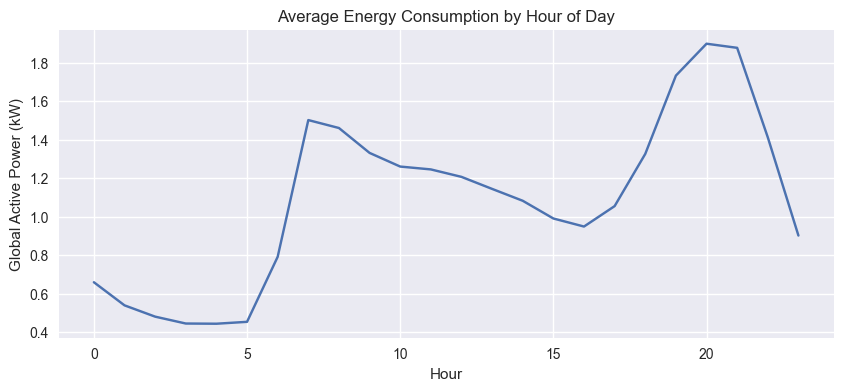

In [5]:
# Average consumption by hour
hourly_avg = df.groupby("hour")["Global_active_power"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot()
plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Global Active Power (kW)")
plt.show()


## 3. Peak and Off-Peak Energy Usage Features

Energy consumption patterns differ significantly between peak hours
(evenings and mornings) and off-peak hours (late night / early morning).

Capturing this behavior helps models:
- Understand demand pressure
- Learn consumption intensity
- Improve forecasting accuracy


In [6]:
# Define peak hours (example: 6 AM – 10 PM)
df["is_peak_hour"] = df["hour"].between(6, 22).astype(int)

# Average power during peak vs off-peak
peak_summary = df.groupby("is_peak_hour")["Global_active_power"].mean()
peak_summary


is_peak_hour
0    0.560694
1    1.310348
Name: Global_active_power, dtype: float64

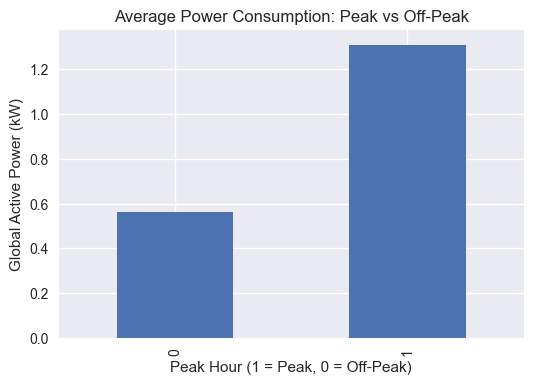

In [7]:
plt.figure(figsize=(6, 4))
peak_summary.plot(kind="bar")
plt.title("Average Power Consumption: Peak vs Off-Peak")
plt.xlabel("Peak Hour (1 = Peak, 0 = Off-Peak)")
plt.ylabel("Global Active Power (kW)")
plt.show()


## 4. Rolling Window Statistics

Rolling statistics help capture short-term trends and smoothing
effects in energy consumption.

We compute rolling averages to represent:
- Short-term behavior (daily)
- Medium-term behavior (weekly)


In [8]:
# Rolling features (window based on minutes)
df["rolling_1day"] = df["Global_active_power"].rolling(window=1440).mean()
df["rolling_7day"] = df["Global_active_power"].rolling(window=10080).mean()

df[["Global_active_power", "rolling_1day", "rolling_7day"]].head(10)


,Global_active_power,rolling_1day,rolling_7day
Datetime,,,
2006-12-16 17:24:00,4.216,NaN,NaN
2006-12-16 17:25:00,5.360,NaN,NaN
2006-12-16 17:26:00,5.374,NaN,NaN
2006-12-16 17:27:00,5.388,NaN,NaN
2006-12-16 17:28:00,3.666,NaN,NaN
2006-12-16 17:29:00,3.520,NaN,NaN
2006-12-16 17:30:00,3.702,NaN,NaN
2006-12-16 17:31:00,3.700,NaN,NaN
2006-12-16 17:32:00,3.668,NaN,NaN


<Figure size 1000x400 with 0 Axes>

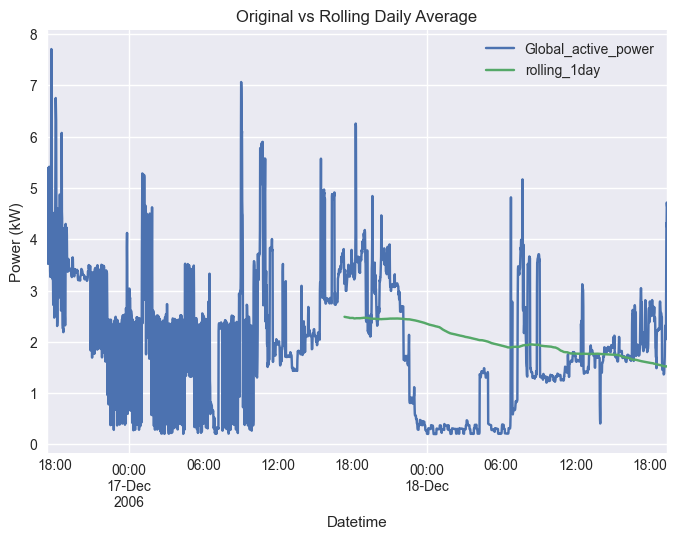

In [9]:
plt.figure(figsize=(10, 4))
df[["Global_active_power", "rolling_1day"]].iloc[:3000].plot()
plt.title("Original vs Rolling Daily Average")
plt.ylabel("Power (kW)")
plt.show()


## 5. Daily Aggregated Features

To reduce noise and support higher-level forecasting,
we aggregate energy consumption at the daily level.

Daily features are useful for:
- Trend detection
- Long-term forecasting
- Model stability


In [10]:
daily_df = df.resample("D").agg({
    "Global_active_power": ["mean", "max", "std"],
    "Sub_metering_1": "mean",
    "Sub_metering_2": "mean",
    "Sub_metering_3": "mean"
})

daily_df.columns = [
    "daily_mean_power",
    "daily_max_power",
    "daily_std_power",
    "kitchen_avg",
    "laundry_avg",
    "hvac_avg"
]

daily_df.head()


,daily_mean_power,daily_max_power,daily_std_power,kitchen_avg,laundry_avg,hvac_avg
Datetime,,,,,,
2006-12-16,3.053475,7.706,1.026338,0.000000,1.378788,12.439394
2006-12-17,2.354486,7.064,1.205795,1.411806,2.907639,9.264583
2006-12-18,1.530435,6.158,1.005074,0.738194,1.820139,9.734722
2006-12-19,1.157079,7.840,1.237602,0.582639,5.279167,4.303472
2006-12-20,1.545658,5.988,1.320968,0.000000,1.838889,9.765972


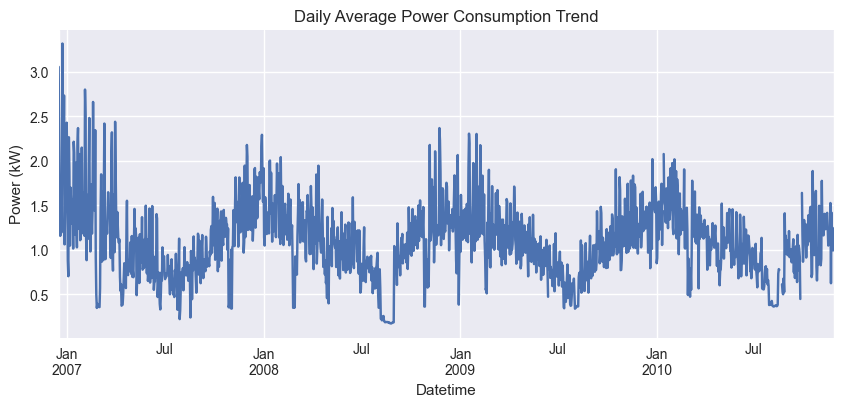

In [11]:
daily_df["daily_mean_power"].plot(figsize=(10,4))
plt.title("Daily Average Power Consumption Trend")
plt.ylabel("Power (kW)")
plt.show()


## 6. Feature Summary

The following table summarizes the engineered features and their purpose.


In [12]:
feature_summary = pd.DataFrame({
    "Feature": daily_df.columns,
    "Purpose": [
        "Average daily energy usage",
        "Peak daily consumption",
        "Consumption variability",
        "Kitchen device usage",
        "Laundry device usage",
        "HVAC / AC usage"
    ]
})

feature_summary


,Feature,Purpose
0,daily_mean_power,Average daily energy usage
1,daily_max_power,Peak daily consumption
2,daily_std_power,Consumption variability
3,kitchen_avg,Kitchen device usage
4,laundry_avg,Laundry device usage
5,hvac_avg,HVAC / AC usage


## 7. Feature Selection for Modeling

Not all engineered features are used for modeling.
We select only meaningful, non-redundant features that help predict
energy consumption effectively.

The target variable:
- Global Active Power (daily mean)

Selected features include:
- Time-based indicators
- Rolling statistics
- Sub-metering behavior


In [13]:
# Target variable
target = "daily_mean_power"

# Feature columns
features = [
    "daily_max_power",
    "daily_std_power",
    "kitchen_avg",
    "laundry_avg",
    "hvac_avg"
]

X = daily_df[features]
y = daily_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (1442, 5)
Target shape: (1442,)


## 8. Train–Test Split (Time-Based)

Since energy consumption data is time-dependent,
we split the dataset chronologically to avoid data leakage.

- First 80% → Training
- Last 20% → Testing


In [14]:
# Calculate split index
split_index = int(len(daily_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (1153, 5) (1153,)
Test set: (289, 5) (289,)


## 9. Feature Scaling

Machine learning models perform better when numerical features
are on a similar scale.

We apply Standard Scaling to ensure:
- Faster convergence
- Fair feature contribution


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]


array([[ 1.26841508,  0.23945771, -1.02976721,  0.01486784,  2.35770822],
       [ 0.88694347,  0.80260477,  0.21797972,  1.03779792,  1.12654805],
       [ 0.34860502,  0.17273125, -0.37735452,  0.31016883,  1.30886327],
       [ 1.34803689,  0.90241665, -0.51483377,  2.62454972, -0.79732179],
       [ 0.24759228,  1.16402199, -1.02976721,  0.32271416,  1.32098171]])

## 10. Final Prepared Dataset

At the end of Milestone 2, the dataset is fully prepared for modeling:

- Cleaned and engineered features
- Time-aware train–test split
- Scaled inputs for ML models

This dataset will be used in Milestone 3 for
model training and evaluation.


In [16]:
summary_df = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [
        X_train.shape,
        X_test.shape,
        y_train.shape,
        y_test.shape
    ]
})

summary_df


,Dataset,Shape
0,X_train,"(1153, 5)"
1,X_test,"(289, 5)"
2,y_train,"(1153,)"
3,y_test,"(289,)"


## 11. Save Feature-Engineered Dataset

The final feature-engineered dataset is saved to disk.
This ensures reproducibility and allows the modeling milestone
to load data without re-running feature engineering.


In [17]:
X_train.to_csv("../data/X_train.csv")
X_test.to_csv("../data/X_test.csv")
y_train.to_csv("../data/y_train.csv")
y_test.to_csv("../data/y_test.csv")


## Export Final Modeling Dataset

Only the selected features and target variable are saved
to ensure efficient and reproducible modeling in Milestone 4.


In [18]:
import pandas as pd
import numpy as np

# Load cleaned dataset from Milestone 2
df = pd.read_csv("../data/household_power_consumption.txt", sep=';', na_values='?')

# Create DateTime index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)

# Basic sanity check
df.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19080\3595406319.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [19]:
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['month'] = df.index.month

df['rolling_mean_24h'] = df['Global_active_power'].rolling(24).mean()


In [20]:
features = ['hour', 'weekday', 'is_weekend', 'month', 'rolling_mean_24h']
target = 'Global_active_power'

df_model = df[features + [target]].dropna()

# Take recent data only
df_model = df_model.tail(50000)


In [21]:
summary_df


,Dataset,Shape
0,X_train,"(1153, 5)"
1,X_test,"(289, 5)"
2,y_train,"(1153,)"
3,y_test,"(289,)"


## Saving Model-Ready Data

After feature engineering and preprocessing, the dataset was split into
time-based training and testing sets.

To ensure reproducibility and simplify model training in later milestones,
the processed datasets are saved as CSV files.


In [22]:
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)
